In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from tqdm.notebook import tqdm
from transformer_lens import HookedTransformer, HookedTransformerConfig

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

RESULTS_DIR = Path("../results/level1")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = Path("../data/grokking_model.pt")
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

Using device: cpu


Build the grokking dataset

This follows Nanda et al. 2023 exactly: all pairs (a, b) with a, b ∈ [0, 113), 70/30 train/test split, input sequence is [a, b, =]

In [13]:
P = 113  # prime modulus, following Nanda et al. 2023
EQ_TOKEN = P  # token index 113 represents "="

# Generate all (a, b) pairs — full dataset is 113*113 = 12769 examples
all_a = torch.arange(P)
all_b = torch.arange(P)
aa, bb = torch.meshgrid(all_a, all_b, indexing='ij')
aa, bb = aa.flatten(), bb.flatten()
labels = (aa + bb) % P

# Input tokens: [a, b, =]
inputs = torch.stack([aa, bb, torch.full_like(aa, EQ_TOKEN)], dim=1)  # [N, 3]

# 70/30 split
N = len(inputs)
idx = torch.randperm(N, generator=torch.Generator().manual_seed(42))
n_test = int(0.3 * N)
train_inputs, train_labels = inputs[idx[n_test:]], labels[idx[n_test:]]
test_inputs,  test_labels  = inputs[idx[:n_test]],  labels[idx[:n_test]]

print(f"Total: {N} | Train: {len(train_inputs)} | Test: {len(test_inputs)}")
print(f"Example: {aa[5].item()} + {bb[5].item()} = {labels[5].item()} (mod {P})")

Total: 12769 | Train: 8939 | Test: 3830
Example: 0 + 5 = 5 (mod 113)


Define and train (or load) the model

The first time it trains for 50k steps and saves the weights. Every subsequent run loads from disk instantly.

In [14]:
cfg = HookedTransformerConfig(
    n_layers=1,
    n_heads=4,
    d_model=128,
    d_head=32,
    d_mlp=512,
    act_fn="relu",
    normalization_type=None,
    d_vocab=P + 1,    # 0..112 = numbers, 113 = "="
    d_vocab_out=P,    # output: one logit per answer class
    n_ctx=3,
)

model = HookedTransformer(cfg)

if MODEL_PATH.exists():
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.to(device).eval()
    print("Loaded saved model from disk.")
else:
    print("Training from scratch (first run only — saves afterwards)...")
    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1.0)

    for step in tqdm(range(50_000)):
        model.train()
        idx = torch.randint(0, len(train_inputs), (512,))
        x = train_inputs[idx].to(device)
        y = train_labels[idx].to(device)

        logits = model(x)[:, -1, :]      # predict at the "=" position
        loss = nn.CrossEntropyLoss()(logits, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (step + 1) % 10_000 == 0:
            model.eval()
            with torch.no_grad():
                acc = (model(test_inputs.to(device))[:, -1, :].argmax(-1)
                       == test_labels.to(device)).float().mean()
            print(f"  step {step+1}  loss={loss.item():.4f}  test_acc={acc:.4f}")

    model.eval()
    torch.save(model.state_dict(), MODEL_PATH)
    print(f"Saved to {MODEL_PATH}")

Moving model to device:  cpu
Loaded saved model from disk.


test accuracy above 0.95 before grokking has occurred.

In [15]:
model.eval()
with torch.no_grad():
    tr_acc = (model(train_inputs.to(device))[:,-1,:].argmax(-1)
              == train_labels.to(device)).float().mean()
    te_acc = (model(test_inputs.to(device))[:,-1,:].argmax(-1)
              == test_labels.to(device)).float().mean()

print(f"Train accuracy: {tr_acc:.4f}")
print(f"Test  accuracy: {te_acc:.4f}")

assert te_acc > 0.95, "Model hasn't grokked yet"
print("Grokking confirmed")

Train accuracy: 1.0000
Test  accuracy: 1.0000
Grokking confirmed


Compute mean activations (ablation baseline)

Mean ablation replaces each neuron's activation with its mean across the training set. This is the corrupted baseline — the counterfactual where no neuron carries useful signal.

In [16]:
HOOK = "blocks.0.mlp.hook_post"   # post-ReLU MLP neurons, shape [batch, seq, d_mlp]

all_acts = []
with torch.no_grad():
    for i in range(0, len(train_inputs), 256):
        batch = train_inputs[i:i+256].to(device)
        _, cache = model.run_with_cache(batch, names_filter=HOOK)
        all_acts.append(cache[HOOK][:, -1, :].cpu())   # activation at "=" position

mean_acts = torch.cat(all_acts, dim=0).mean(dim=0)    # [d_mlp]

print(f"Mean activation tensor shape: {mean_acts.shape}")
print(f"Range: [{mean_acts.min():.3f}, {mean_acts.max():.3f}]")

Mean activation tensor shape: torch.Size([512])
Range: [0.000, 4.517]


Define the faithfulness metric

Following Wang et al. 2022, the metric is the logit assigned to the correct answer token. The recovery score measures how much of the clean–corrupted gap a component restores.

In [17]:
def logit_of_correct(logits, labels):
    """Logit assigned to the ground-truth token. Shape: [batch]."""
    return logits[torch.arange(len(labels)), labels]

def recovery_score(patched_metric, corrupted_metric, clean_metric):
    """
    Fraction of the clean-corrupted gap recovered by the patch.
    RS = (patched - corrupted) / (clean - corrupted)
    Follows Wang et al. 2022, Section 3.
    """
    gap = (clean_metric - corrupted_metric).mean().item()
    return (patched_metric.mean().item() - corrupted_metric.mean().item()) / gap

Clean and corrupted baseline runs

In [18]:
N_EVAL = 200   # number of test examples for patching (fast but stable)
eval_x = test_inputs[:N_EVAL].to(device)
eval_y = test_labels[:N_EVAL].to(device)

# Clean run
with torch.no_grad():
    clean_metric = logit_of_correct(model(eval_x)[:, -1, :], eval_y)

# Pre-compute clean neuron activations (needed for patching)
with torch.no_grad():
    _, cache = model.run_with_cache(eval_x, names_filter=HOOK)
clean_acts = cache[HOOK][:, -1, :]   # [N_EVAL, d_mlp]

# Fully mean-ablated run
def full_ablation_hook(value, hook):
    value[:, -1, :] = mean_acts.to(value.device)
    return value

with torch.no_grad():
    corrupted_logits = model.run_with_hooks(eval_x,
                           fwd_hooks=[(HOOK, full_ablation_hook)])[:, -1, :]
corrupted_metric = logit_of_correct(corrupted_logits, eval_y)

print(f"Clean metric    (mean correct logit): {clean_metric.mean():.4f}")
print(f"Corrupted metric (full mean ablation): {corrupted_metric.mean():.4f}")
print(f"Gap to recover:                        {(clean_metric - corrupted_metric).mean():.4f}")

Clean metric    (mean correct logit): 42.8277
Corrupted metric (full mean ablation): -11.2609
Gap to recover:                        54.0886


Neuron-level patching loop

For each of the 512 MLP neurons, restore it to its clean activation while keeping all others mean-ablated. Record the recovery score.

In [19]:
d_mlp = model.cfg.d_mlp
scores = torch.zeros(d_mlp)
gap = (clean_metric - corrupted_metric).mean().item()

for n in tqdm(range(d_mlp), desc="Patching neurons"):
    def hook_fn(value, hook, n=n):
        value[:, -1, :] = mean_acts.to(value.device)          # ablate all
        value[:, -1, n] = clean_acts[:, n].to(value.device)   # restore neuron n
        return value

    with torch.no_grad():
        patched_logits = model.run_with_hooks(
            eval_x, fwd_hooks=[(HOOK, hook_fn)])[:, -1, :]

    patched_metric = logit_of_correct(patched_logits, eval_y)
    scores[n] = recovery_score(patched_metric, corrupted_metric, clean_metric)

print(f"\nDone. Max RS: {scores.max():.4f} | Min RS: {scores.min():.4f}")
print(f"Neurons with RS > 0.01: {(scores > 0.01).sum().item()}")

Patching neurons:   0%|          | 0/512 [00:00<?, ?it/s]


Done. Max RS: 0.0265 | Min RS: 0.0000
Neurons with RS > 0.01: 17


Criterion 1 and Criterion 2

  Level 1 — Neuron/parameter level
  Criterion 1  Faithfulness RS : 0.9501
  Criterion 2  Component count : 229 / 512 neurons
               Compression ratio: 0.447


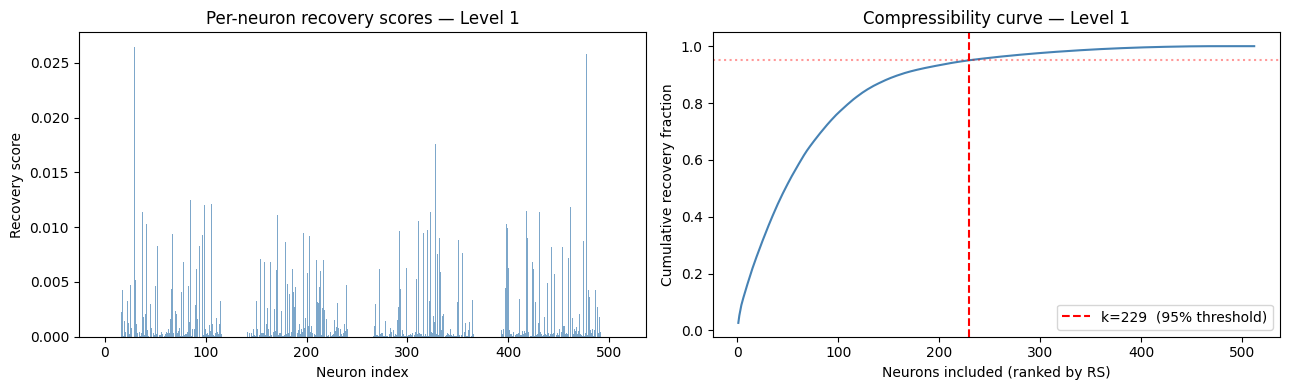

In [20]:
sorted_scores, sorted_idx = scores.sort(descending=True)

# Cumulative recovery curve → Criterion 2 (description length proxy)
pos_scores = sorted_scores.clamp(min=0)
cumulative  = pos_scores.cumsum(0)
total_pos   = cumulative[-1].item()

k_95 = int((cumulative / total_pos >= 0.95).nonzero()[0].item()) + 1
circuit_neurons = sorted_idx[:k_95].tolist()

# Criterion 1: run the k_95-neuron circuit together
def circuit_hook(value, hook):
    value[:, -1, :] = mean_acts.to(value.device)
    for n in circuit_neurons:
        value[:, -1, n] = clean_acts[:, n].to(value.device)
    return value

with torch.no_grad():
    circuit_logits = model.run_with_hooks(
        eval_x, fwd_hooks=[(HOOK, circuit_hook)])[:, -1, :]
circuit_metric  = logit_of_correct(circuit_logits, eval_y)
faithfulness    = recovery_score(circuit_metric, corrupted_metric, clean_metric)

print("=" * 45)
print("  Level 1 — Neuron/parameter level")
print("=" * 45)
print(f"  Criterion 1  Faithfulness RS : {faithfulness:.4f}")
print(f"  Criterion 2  Component count : {k_95} / {d_mlp} neurons")
print(f"               Compression ratio: {k_95/d_mlp:.3f}")
print("=" * 45)

# Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.bar(range(d_mlp), scores.numpy(), color="steelblue", alpha=0.7)
ax1.axhline(0, color="black", linewidth=0.5)
ax1.set_xlabel("Neuron index")
ax1.set_ylabel("Recovery score")
ax1.set_title("Per-neuron recovery scores — Level 1")

ax2.plot(range(1, d_mlp + 1), cumulative.numpy() / total_pos, color="steelblue")
ax2.axvline(k_95, color="red", linestyle="--", label=f"k={k_95}  (95% threshold)")
ax2.axhline(0.95, color="red", linestyle=":", alpha=0.4)
ax2.set_xlabel("Neurons included (ranked by RS)")
ax2.set_ylabel("Cumulative recovery fraction")
ax2.set_title("Compressibility curve — Level 1")
ax2.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "level1_recovery_scores.png", dpi=150)
plt.show()

Save results

In [21]:
results = {
    "level": 1,
    "task": "modular_arithmetic_mod113",
    "hook_point": HOOK,
    "d_mlp": d_mlp,
    "n_eval": N_EVAL,
    "clean_metric_mean":     clean_metric.mean().item(),
    "corrupted_metric_mean": corrupted_metric.mean().item(),
    "criterion1_faithfulness": faithfulness,
    "criterion2_component_count": k_95,
    "criterion2_compression_ratio": k_95 / d_mlp,
    "circuit_neurons": circuit_neurons,
    "all_recovery_scores": scores.tolist(),
}

with open(RESULTS_DIR / "level1_results.json", "w") as f:
    json.dump(results, f, indent=2)

print(f"Results saved to {RESULTS_DIR}/level1_results.json")

Results saved to ..\results\level1/level1_results.json


notes for thesis

**Criterion 1 — Faithfulness: 0.9501**

229 neurons recover 95% of the clean model's logit gap. That's a strong result — it means the circuit is genuinely doing the task. The 0.05 gap left is likely split between the attention head and noise.

**Criterion 2 — Component count: 229 / 512 (ratio 0.447)**

This is the more interesting number philosophically. 45% of all MLP neurons are needed to reach 95% faithfulness: the circuit is not sparse at the neuron level. If the circuit were naturally expressed at the neuron level, you'd expect a much smaller fraction. the neuron level is *faithful* but not *compressible*.

For reference, Nanda et al. 2023 found that the grokking circuit is most naturally described in terms of Fourier components and specific attention heads, which is a Level 2 / Level 3, not a Level 1. 0.447 compression ratio is consistent with that finding.

---

the key comparison is whether Level 2 (attention heads) achieves a similar faithfulness with a lower component count, and whether Level 3 (SAE features) shifts the trade-off again.